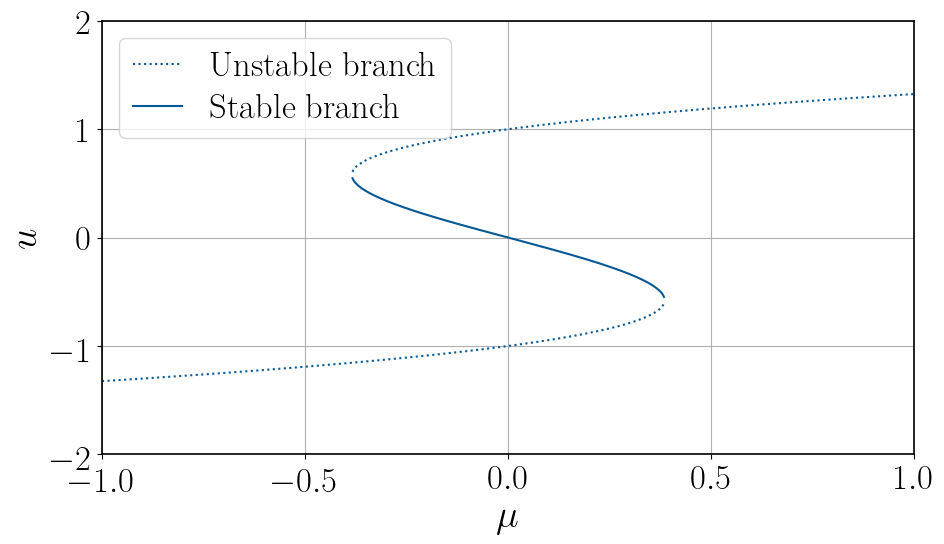

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Parameter range
mu_values = np.linspace(-1, 1, 1000)

plt.rcParams.update({
    "text.usetex": True,
    "text.latex.preamble": r"\usepackage{lmodern}",
    "font.family": "lmodern",

    "font.size": 25,          # Base font size
    "axes.labelsize": 28,     # Axis labels
    "axes.titlesize": 30,     # Titles (if used)
    "xtick.labelsize": 25,
    "ytick.labelsize": 25,
    "legend.fontsize": 25,

    "axes.linewidth": 1.2,
    "grid.linewidth": 0.8,
})

# Prepare lists for three branches
mu_low, u_low = [], []
mu_mid, u_mid = [], []
mu_high, u_high = [], []

# Threshold for branch classification (fold points at ±1/√3)
threshold = 1/np.sqrt(3)
bluemathlab="#065895"

for mu in mu_values:
    roots = np.roots([1, 0, -1, -mu])
    real_roots = np.real(roots[np.isreal(roots)])
    # Sort roots for classification
    for u in real_roots:
        if u < -threshold:
            mu_low.append(mu)
            u_low.append(u)
        elif u > threshold:
            mu_high.append(mu)
            u_high.append(u)
        else:
            mu_mid.append(mu)
            u_mid.append(u)

# Plotting
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(mu_low, u_low, linestyle=':', color=bluemathlab, label='Unstable branch')
ax.plot(mu_mid, u_mid, linestyle='-', color=bluemathlab, label='Stable branch')
ax.plot(mu_high, u_high, linestyle=':', color=bluemathlab,)
ax.set_xlabel(r"$\mu$")
ax.set_ylabel(r"$u$")

ax.set_xlim(-1, 1)
ax.set_ylim(-2, 2)

ax.grid(True)

ax.legend(
    loc="upper left",
    frameon=True,
    borderpad=0.4,
    labelspacing=0.3,
    handlelength=1.4
)
# ax.set_title(r"Pitchfork bifurcation", pad=12)
fig.tight_layout()
fig.savefig("plots/S_shaped.pdf")
fig.savefig("plots/S_shaped.png")
plt.show()
